In [38]:
# Core libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import time

from transformer_models import VisionTransformer

# Configure device
if torch.cuda.is_available():
    compute_device = torch.device('cuda')
    print("Using CUDA GPU")
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    compute_device = torch.device('mps')
    print("Using Apple Silicon GPU (MPS)")
else:
    compute_device = torch.device('cpu')
    print("Using CPU")


Using Apple Silicon GPU (MPS)


In [39]:
class FashionMNISTDataLoader:
    """
    Data loading utility class for FashionMNIST dataset.
    Handles dataset download, preprocessing, and DataLoader creation.
    """
    
    def __init__(self, data_root='./data', batch_size=128, 
                 train_samples=600, test_samples=200):
        self.data_root = data_root
        self.batch_size = batch_size
        self.train_samples = train_samples
        self.test_samples = test_samples
        
    def create_transforms(self):
        """Create data transformation pipeline for FashionMNIST"""
        return transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=(0.5,), std=(0.5,))  # Normalize to [-1, 1]
        ])
    
    def prepare_datasets(self):
        """Download and prepare FashionMNIST datasets"""
        transform = self.create_transforms()
        
        print("Preparing FashionMNIST training dataset...")
        full_train = torchvision.datasets.FashionMNIST(
            root=self.data_root, 
            train=True, 
            download=True, 
            transform=transform
        )
        
        print("Preparing FashionMNIST test dataset...")
        full_test = torchvision.datasets.FashionMNIST(
            root=self.data_root, 
            train=False, 
            download=True, 
            transform=transform
        )
        
        # Create subsets for MWE-CPU
        print(f"\nCreating subsets: {self.train_samples}/{len(full_train)} train, "
              f"{self.test_samples}/{len(full_test)} test samples")
        train_subset = Subset(full_train, torch.arange(self.train_samples))
        test_subset = Subset(full_test, torch.arange(self.test_samples))
        
        return train_subset, test_subset
    
    def create_loaders(self):
        """Create DataLoader objects for training and testing"""
        train_data, test_data = self.prepare_datasets()
        
        # Configure DataLoader workers based on device
        num_workers = 0 if compute_device.type == 'cpu' else 2
        
        train_loader = DataLoader(
            train_data,
            batch_size=self.batch_size,
            shuffle=True,
            num_workers=num_workers,
            pin_memory=(compute_device.type != 'cpu')
        )
        
        test_loader = DataLoader(
            test_data,
            batch_size=self.batch_size,
            shuffle=False,
            num_workers=num_workers,
            pin_memory=(compute_device.type != 'cpu')
        )
        
        return train_loader, test_loader

# Initialize data loader
data_manager = FashionMNISTDataLoader(
    batch_size=64,
    train_samples=1500,
    test_samples=500
)
train_data_loader, test_data_loader = data_manager.create_loaders()
print(f"\nData loaders created: {len(train_data_loader)} train batches, {len(test_data_loader)} test batches")
print(f"Batch size: {data_manager.batch_size}")
print(f"Dataset: FashionMNIST subset ({data_manager.train_samples} train, {data_manager.test_samples} test)")


Preparing FashionMNIST training dataset...
Preparing FashionMNIST test dataset...

Creating subsets: 1500/60000 train, 500/10000 test samples

Data loaders created: 24 train batches, 8 test batches
Batch size: 64
Dataset: FashionMNIST subset (1500 train, 500 test)


In [40]:
# Initialize Vision Transformer model
vit_model = VisionTransformer(
    in_channels=1,
    img_size=28,
    patch_size=4,
    emb_size=32,
    num_classes=10,
    depth=4,
    num_heads=4,
    forward_expansion=2,
    dropout=0.0
).to(compute_device)

# Display model information
total_params = sum(p.numel() for p in vit_model.parameters())
trainable_params = sum(p.numel() for p in vit_model.parameters() if p.requires_grad)

print(f"Model initialized on: {compute_device}")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Model: Vision Transformer")
print(f"Input: 28x28 grayscale images → 10 classes")
print(f"Configuration: emb_size=32, depth=4, heads=4, expansion=2x")


Model initialized on: mps
Total parameters: 36,746
Trainable parameters: 36,746
Model: Vision Transformer
Input: 28x28 grayscale images → 10 classes
Configuration: emb_size=32, depth=4, heads=4, expansion=2x


In [41]:
import torchmetrics
from torchmetrics.classification import (
    MulticlassAccuracy, 
    MulticlassAUROC, 
    MulticlassF1Score, 
    MulticlassPrecision, 
    MulticlassRecall
)

class MetricsManager:
    """
    Manages all evaluation metrics for the classification task.
    Uses separate metric objects to ensure correct computation.
    """
    def __init__(self, num_classes=10, device=None):
        self.num_classes = num_classes
        self.device = device
        
        # Initialize all metrics with proper configuration
        # Note: top1 with top_k=1 is the same as regular accuracy
        self.accuracy = MulticlassAccuracy(num_classes=num_classes).to(device)
        self.auc = MulticlassAUROC(num_classes=num_classes).to(device)
        self.f1 = MulticlassF1Score(num_classes=num_classes, average="macro").to(device)
        self.precision = MulticlassPrecision(num_classes=num_classes, average="macro").to(device)
        self.recall = MulticlassRecall(num_classes=num_classes, average="macro").to(device)
        self.top1 = MulticlassAccuracy(num_classes=num_classes, top_k=1).to(device)
        self.top5 = MulticlassAccuracy(num_classes=num_classes, top_k=5).to(device)
    
    def reset_all(self):
        """Reset all metrics to zero"""
        self.accuracy.reset()
        self.auc.reset()
        self.f1.reset()
        self.precision.reset()
        self.recall.reset()
        self.top1.reset()
        self.top5.reset()
    
    def update(self, logits, targets):
        """
        Update all metrics with logits and targets.
        
        Args:
            logits: Model output logits [batch_size, num_classes]
            targets: Ground truth labels [batch_size]
        """
        import torch
        # Compute probabilities for AUC
        probabilities = torch.softmax(logits, dim=1)
        
        # Update metrics: most use logits, AUC uses probabilities
        self.accuracy.update(logits, targets)
        self.auc.update(probabilities, targets)
        self.f1.update(logits, targets)
        self.precision.update(logits, targets)
        self.recall.update(logits, targets)
        self.top1.update(logits, targets)
        self.top5.update(logits, targets)
    
    def compute_all(self):
        """Compute and return all metric values in a fixed order"""
        return {
            'accuracy': self.accuracy.compute().item(),
            'auc': self.auc.compute().item(),
            'f1': self.f1.compute().item(),
            'precision': self.precision.compute().item(),
            'recall': self.recall.compute().item(),
            'top1': self.top1.compute().item(),
            'top5': self.top5.compute().item(),
        }

# Initialize separate metrics for training and validation
train_metrics = MetricsManager(num_classes=10, device=compute_device)
val_metrics = MetricsManager(num_classes=10, device=compute_device)

def visualize_attention_patterns(sample_image, attention_map, class_label, save_path=None):
    """
    Visualize attention patterns from the Vision Transformer.
    
    Args:
        sample_image: Single image tensor [C, H, W]
        attention_map: Attention weights grid [H_patches, W_patches]
        class_label: Class label for the image
        save_path: Optional path to save the figure as PDF
    """
    plt.style.use('seaborn-v0_8-darkgrid')
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # Original image (grayscale)
    img_array = sample_image.squeeze().cpu().numpy()
    axes[0].imshow(img_array, cmap='bone', vmin=img_array.min(), vmax=img_array.max())
    axes[0].set_title(f'Input Image (Class: {class_label})', fontsize=13, fontweight='bold', pad=10)
    axes[0].axis('off')
    
    # Attention heatmap
    attn_np = attention_map.cpu().numpy()
    im = axes[1].imshow(attn_np, cmap='plasma', interpolation='bicubic', aspect='auto')
    axes[1].set_title('Attention Heatmap', fontsize=13, fontweight='bold', pad=10)
    cbar = plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
    cbar.set_label('Attention Weight', rotation=270, labelpad=15, fontsize=11)
    axes[1].axis('off')
    
    # Overlay visualization
    H, W = img_array.shape
    attn_resized = torch.nn.functional.interpolate(
        attention_map[None, None],
        size=(H, W),
        mode='bilinear',
        align_corners=False
    )[0, 0].cpu().numpy()
    
    axes[2].imshow(img_array, cmap='bone', alpha=0.7, vmin=img_array.min(), vmax=img_array.max())
    axes[2].imshow(attn_resized, cmap='plasma', alpha=0.6, interpolation='bicubic')
    axes[2].set_title('Attention Overlay', fontsize=13, fontweight='bold', pad=10)
    axes[2].axis('off')
    
    plt.suptitle(f'Vision Transformer Attention Visualization (Class: {class_label})', 
                 fontsize=15, fontweight='bold', y=0.98)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    
    # Save as PDF if path provided
    if save_path:
        fig.savefig(save_path, format='pdf', bbox_inches='tight', dpi=300)
        print(f"Attention visualization saved to {save_path}")
    
    return fig

print("Metrics and visualization utilities initialized")


Metrics and visualization utilities initialized


In [42]:
class TrainingPipeline:
    """
    Encapsulates the training and evaluation logic for the Vision Transformer.
    """
    
    def __init__(self, model, train_metrics, val_metrics, device):
        self.model = model
        self.train_metrics = train_metrics
        self.val_metrics = val_metrics
        self.device = device
    
    def train_epoch(self, data_loader, loss_fn, optimizer):
        """
        Train the model for one epoch.
        
        Returns:
            Dictionary containing training metrics
        """
        self.model.train()
        epoch_loss = 0.0
        self.train_metrics.reset_all()
        
        for batch_images, batch_labels in data_loader:
            # Move data to device
            batch_images = batch_images.to(self.device, non_blocking=True)
            batch_labels = batch_labels.to(self.device, non_blocking=True)
            
            # Forward pass
            logits = self.model(batch_images)
            batch_loss = loss_fn(logits, batch_labels)
            
            # Backward pass
            optimizer.zero_grad()
            batch_loss.backward()
            optimizer.step()
            
            # Update metrics with logits (metrics will handle softmax internally)
            self.train_metrics.update(logits, batch_labels)
            
            epoch_loss += batch_loss.item()
        
        # Compute average loss and metrics
        avg_loss = epoch_loss / len(data_loader)
        metric_results = self.train_metrics.compute_all()
        
        return {
            'loss': avg_loss,
            **metric_results
        }
    
    def evaluate_model(self, data_loader, loss_fn, visualize_attention=False):
        """
        Evaluate the model on the test set.
        
        Args:
            visualize_attention: If True, generate attention visualization
        
        Returns:
            Dictionary containing evaluation metrics and optional visualization data
        """
        self.model.eval()
        epoch_loss = 0.0
        self.val_metrics.reset_all()
        
        sample_image = None
        sample_label = None
        attention_visualization = None
        
        with torch.no_grad():
            for batch_images, batch_labels in data_loader:
                batch_images = batch_images.to(self.device, non_blocking=True)
                batch_labels = batch_labels.to(self.device, non_blocking=True)
                
                # Forward pass
                logits = self.model(batch_images)
                batch_loss = loss_fn(logits, batch_labels)
                
                # Update metrics with logits (metrics will handle softmax internally)
                self.val_metrics.update(logits, batch_labels)
                
                epoch_loss += batch_loss.item()
                
                # Store first sample for attention visualization
                if visualize_attention and sample_image is None:
                    sample_image = batch_images[0]
                    sample_label = batch_labels[0].item()
                    
                    # Extract attention weights from last transformer layer
                    last_encoder = self.model.transformer_encoders[-1]
                    attn_weights = last_encoder.mha.attention_weights[0]  # [num_heads, num_patches+1, num_patches+1]
                    
                    # Average across attention heads
                    attn_avg = attn_weights.mean(dim=0)  # [num_patches+1, num_patches+1]
                    
                    # Get CLS token attention to patches (skip CLS token itself)
                    cls_attn = attn_avg[0, 1:]  # [num_patches]
                    
                    # Reshape to spatial grid (7x7 for 28x28 image with 4x4 patches)
                    patch_grid_size = 28 // 4
                    attention_visualization = cls_attn.reshape(patch_grid_size, patch_grid_size)
                    
                    # Normalize to [0, 1]
                    attn_min = attention_visualization.min()
                    attn_max = attention_visualization.max()
                    if attn_max > attn_min:
                        attention_visualization = (attention_visualization - attn_min) / (attn_max - attn_min)
        
        avg_loss = epoch_loss / len(data_loader)
        metric_results = self.val_metrics.compute_all()
        
        result = {
            'loss': avg_loss,
            **metric_results
        }
        
        if visualize_attention and sample_image is not None:
            result['attention_viz'] = {
                'image': sample_image,
                'attention': attention_visualization,
                'label': sample_label
            }
        
        return result

# Initialize training pipeline with separate metrics for train and validation
trainer = TrainingPipeline(vit_model, train_metrics, val_metrics, compute_device)
print("Training pipeline initialized")


Training pipeline initialized


Starting Training Process
Total epochs: 8
Initial learning rate: 0.0008
Training samples: 1500
Test samples: 500


/Users/avinashashokar/Documents/college/dl/project/new/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)



Epoch 1/8 (Time: 3.76s, LR: 0.000800)
----------------------------------------------------------------------
Training   | Loss: 2.2850 | Acc: 0.1521 | AUC: 0.5773 | F1: 0.1086
Validation | Loss: 2.2142 | Acc: 0.1945 | AUC: 0.6831 | F1: 0.0883
           | Precision: 0.0589 | Recall: 0.1945
           | Top-1: 0.1945 | Top-5: 0.6623

Epoch 2/8 (Time: 3.07s, LR: 0.000800)
----------------------------------------------------------------------
Training   | Loss: 2.1251 | Acc: 0.1984 | AUC: 0.6680 | F1: 0.1009
Validation | Loss: 2.0669 | Acc: 0.2258 | AUC: 0.7206 | F1: 0.1459
           | Precision: 0.1484 | Recall: 0.2258
           | Top-1: 0.2258 | Top-5: 0.7654

Epoch 3/8 (Time: 2.85s, LR: 0.000680)
----------------------------------------------------------------------
Training   | Loss: 1.9959 | Acc: 0.2498 | AUC: 0.7243 | F1: 0.1947
Validation | Loss: 1.9309 | Acc: 0.2886 | AUC: 0.7817 | F1: 0.2115
           | Precision: 0.2243 | Recall: 0.2886
           | Top-1: 0.2886 | Top-5: 0.

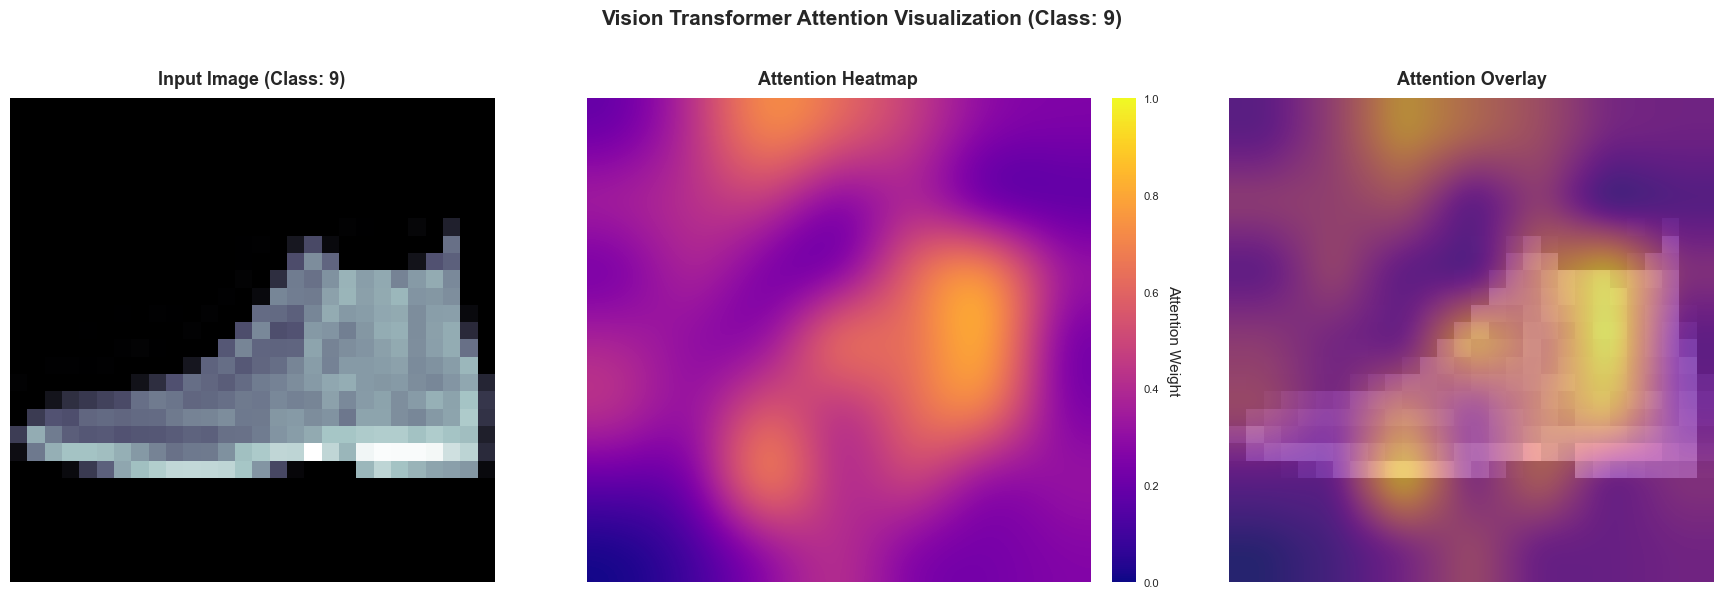


Training completed in 24.74 seconds (0.41 minutes)


In [43]:
# Training Configuration
EPOCHS = 8
INITIAL_LEARNING_RATE = 0.0008
WEIGHT_DECAY = 1e-4

# Initialize loss function and optimizer
loss_function = nn.CrossEntropyLoss()
optimizer_adam = optim.Adam(
    vit_model.parameters(), 
    lr=INITIAL_LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    betas=(0.9, 0.999)
)

# Learning rate scheduler (step decay)
scheduler = optim.lr_scheduler.StepLR(
    optimizer_adam, 
    step_size=3,
    gamma=0.85
)

# Storage for training history
training_history = defaultdict(list)
validation_history = defaultdict(list)

print("=" * 70)
print("Starting Training Process")
print("=" * 70)
print(f"Total epochs: {EPOCHS}")
print(f"Initial learning rate: {INITIAL_LEARNING_RATE}")
print(f"Training samples: {data_manager.train_samples}")
print(f"Test samples: {data_manager.test_samples}")
print("=" * 70)

start_time = time.time()

for current_epoch in range(1, EPOCHS + 1):
    epoch_start = time.time()
    
    # Training phase
    train_results = trainer.train_epoch(
        train_data_loader, 
        loss_function, 
        optimizer_adam
    )
    
    # Evaluation phase (with attention visualization on last epoch)
    show_attention = (current_epoch == EPOCHS)
    val_results = trainer.evaluate_model(
        test_data_loader, 
        loss_function,
        visualize_attention=show_attention
    )
    
    # Update learning rate
    scheduler.step()
    current_lr = scheduler.get_last_lr()[0]
    
    # Store results
    for key, value in train_results.items():
        training_history[key].append(value)
    for key, value in val_results.items():
        if key != 'attention_viz':  # Don't store visualization data
            validation_history[key].append(value)
    
    # Display epoch results
    epoch_time = time.time() - epoch_start
    print(f"\nEpoch {current_epoch}/{EPOCHS} (Time: {epoch_time:.2f}s, LR: {current_lr:.6f})")
    print("-" * 70)
    print(f"Training   | Loss: {train_results['loss']:.4f} | Acc: {train_results['accuracy']:.4f} | "
          f"AUC: {train_results['auc']:.4f} | F1: {train_results['f1']:.4f}")
    print(f"Validation | Loss: {val_results['loss']:.4f} | Acc: {val_results['accuracy']:.4f} | "
          f"AUC: {val_results['auc']:.4f} | F1: {val_results['f1']:.4f}")
    print(f"           | Precision: {val_results['precision']:.4f} | Recall: {val_results['recall']:.4f}")
    print(f"           | Top-1: {val_results['top1']:.4f} | Top-5: {val_results['top5']:.4f}")
    
    # Show attention visualization on last epoch and save as PDF
    if show_attention and 'attention_viz' in val_results:
        viz_data = val_results['attention_viz']
        import os
        os.makedirs('../result', exist_ok=True)
        save_path = '../result/attention_visualization.pdf'
        fig = visualize_attention_patterns(
            viz_data['image'],
            viz_data['attention'],
            viz_data['label'],
            save_path=save_path
        )
        plt.show()

total_time = time.time() - start_time
print("\n" + "=" * 70)
print(f"Training completed in {total_time:.2f} seconds ({total_time/60:.2f} minutes)")
print("=" * 70)


Training curves saved to ../result/training_curves.pdf
Results exported to ../result/training_results.csv

All results and visualizations saved to ../result/ directory


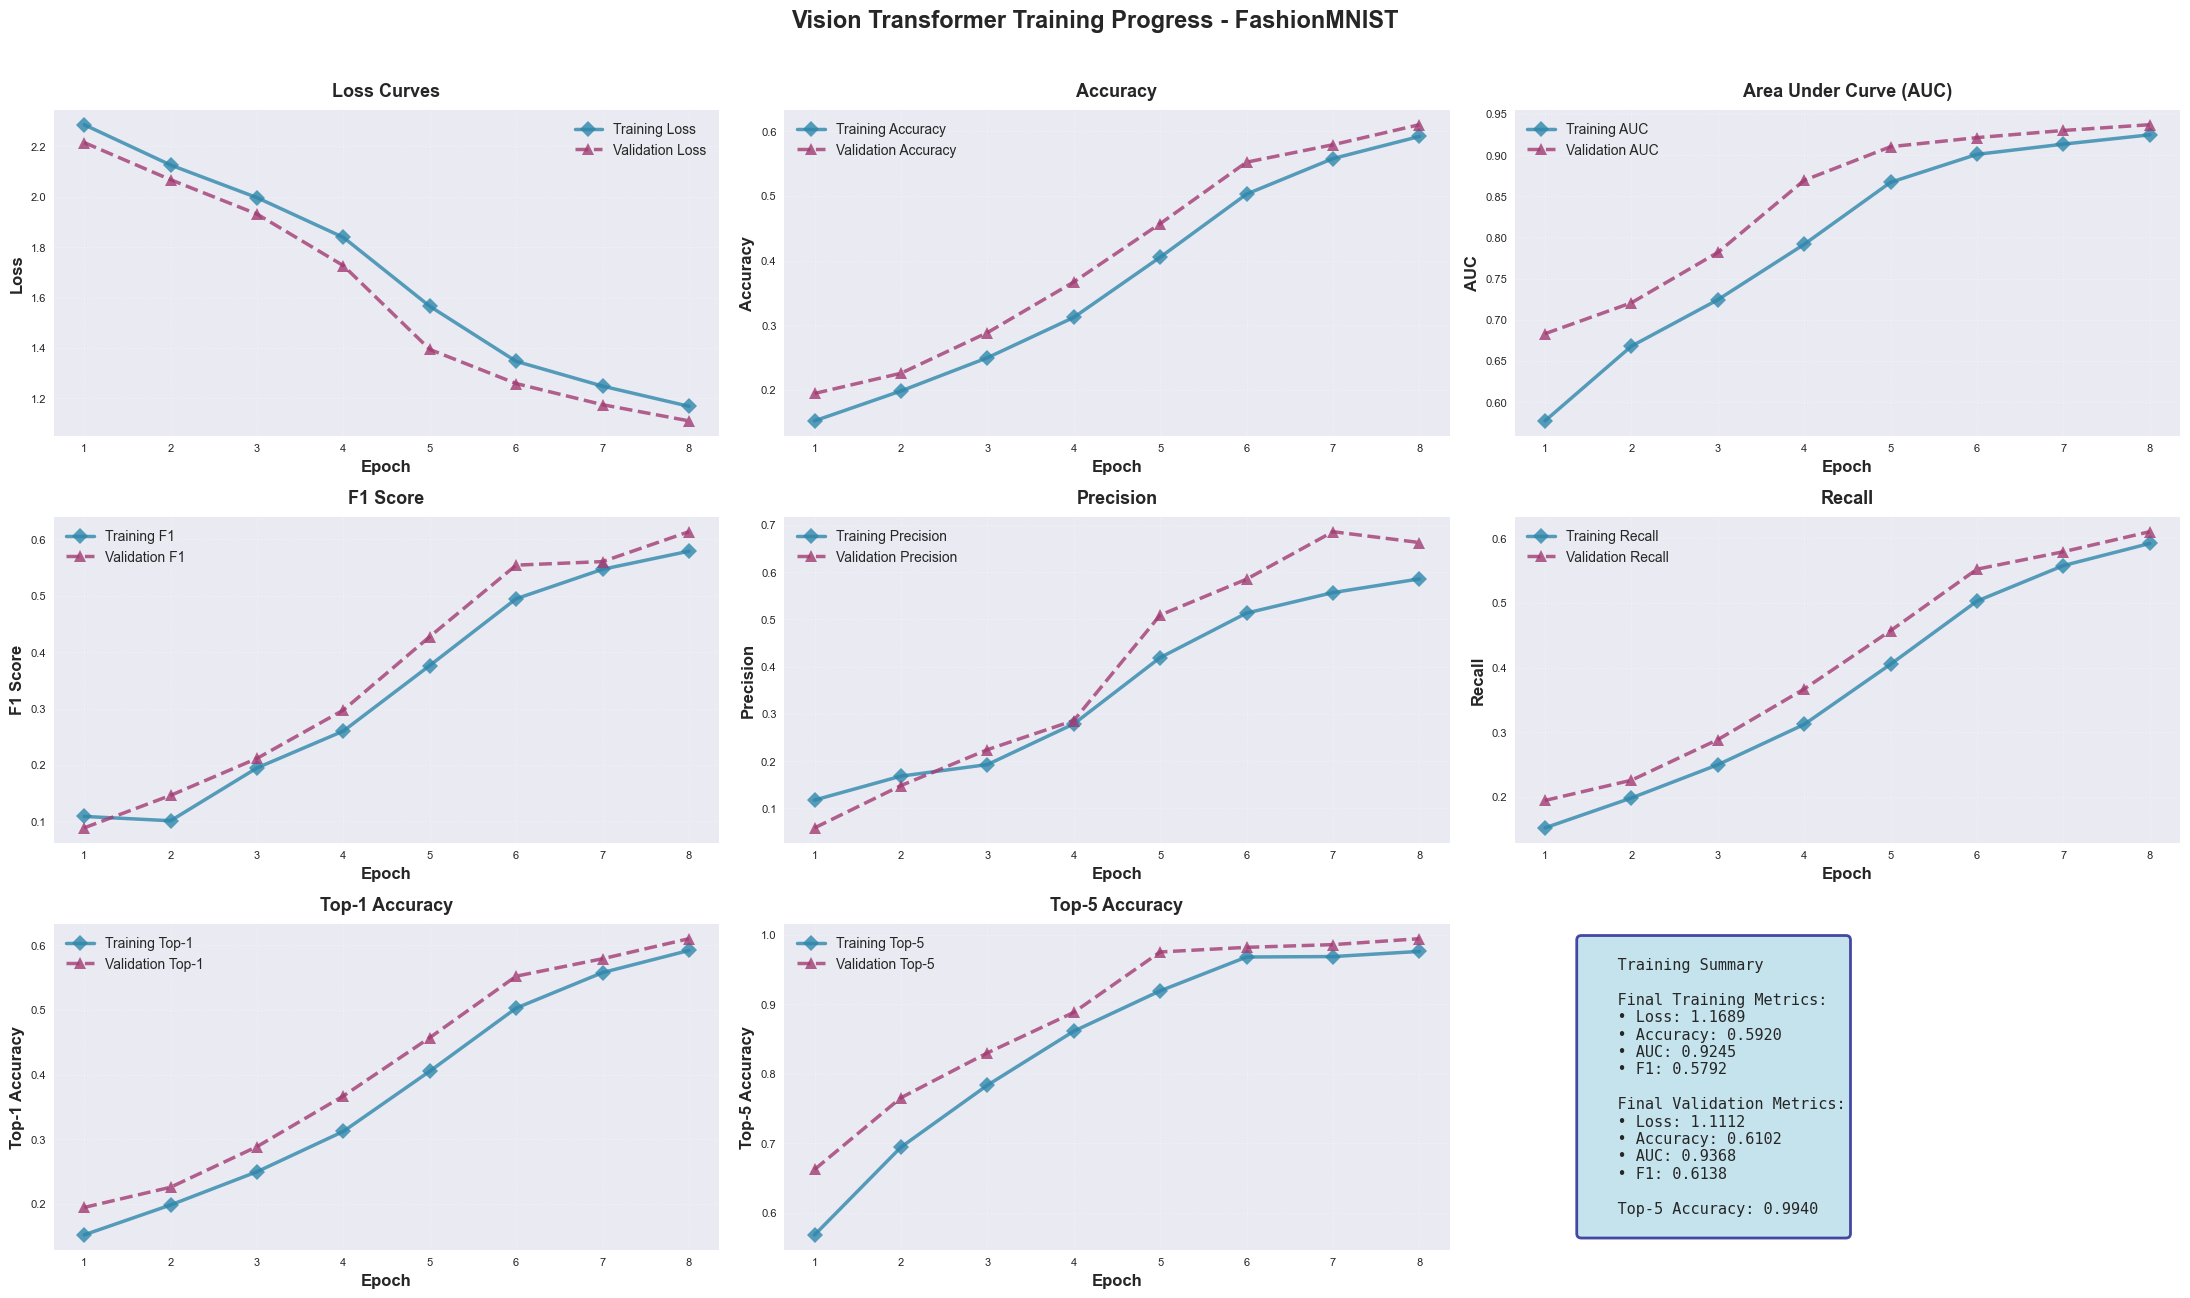

In [44]:
def plot_training_curves(train_history, val_history, num_epochs, save_path=None):
    """
    Create comprehensive visualization of training progress.
    
    Args:
        train_history: Dictionary of training metrics over epochs
        val_history: Dictionary of validation metrics over epochs
        num_epochs: Number of training epochs
        save_path: Optional path to save the figure as PDF
    """
    plt.style.use('seaborn-v0_8-paper')
    epochs = range(1, num_epochs + 1)
    
    fig = plt.figure(figsize=(22, 13))
    
    train_color = '#2E86AB'
    val_color = '#A23B72'
    train_marker = 'D'
    val_marker = '^'
    
    # 1. Loss curve
    ax1 = plt.subplot(3, 3, 1)
    ax1.plot(epochs, train_history['loss'], marker=train_marker, color=train_color, 
             label='Training Loss', linewidth=2.5, markersize=8, linestyle='-', alpha=0.8)
    ax1.plot(epochs, val_history['loss'], marker=val_marker, color=val_color, 
             label='Validation Loss', linewidth=2.5, markersize=8, linestyle='--', alpha=0.8)
    ax1.set_xlabel('Epoch', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Loss', fontsize=12, fontweight='bold')
    ax1.set_title('Loss Curves', fontsize=13, fontweight='bold', pad=10)
    ax1.grid(True, alpha=0.4, linestyle=':')
    ax1.legend(loc='best', fontsize=10, framealpha=0.9)
    
    # 2. Accuracy
    ax2 = plt.subplot(3, 3, 2)
    ax2.plot(epochs, train_history['accuracy'], marker=train_marker, color=train_color, 
             label='Training Accuracy', linewidth=2.5, markersize=8, linestyle='-', alpha=0.8)
    ax2.plot(epochs, val_history['accuracy'], marker=val_marker, color=val_color, 
             label='Validation Accuracy', linewidth=2.5, markersize=8, linestyle='--', alpha=0.8)
    ax2.set_xlabel('Epoch', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
    ax2.set_title('Accuracy', fontsize=13, fontweight='bold', pad=10)
    ax2.grid(True, alpha=0.4, linestyle=':')
    ax2.legend(loc='best', fontsize=10, framealpha=0.9)
    
    # 3. AUC
    ax3 = plt.subplot(3, 3, 3)
    ax3.plot(epochs, train_history['auc'], marker=train_marker, color=train_color, 
             label='Training AUC', linewidth=2.5, markersize=8, linestyle='-', alpha=0.8)
    ax3.plot(epochs, val_history['auc'], marker=val_marker, color=val_color, 
             label='Validation AUC', linewidth=2.5, markersize=8, linestyle='--', alpha=0.8)
    ax3.set_xlabel('Epoch', fontsize=12, fontweight='bold')
    ax3.set_ylabel('AUC', fontsize=12, fontweight='bold')
    ax3.set_title('Area Under Curve (AUC)', fontsize=13, fontweight='bold', pad=10)
    ax3.grid(True, alpha=0.4, linestyle=':')
    ax3.legend(loc='best', fontsize=10, framealpha=0.9)
    
    # 4. F1 Score
    ax4 = plt.subplot(3, 3, 4)
    ax4.plot(epochs, train_history['f1'], marker=train_marker, color=train_color, 
             label='Training F1', linewidth=2.5, markersize=8, linestyle='-', alpha=0.8)
    ax4.plot(epochs, val_history['f1'], marker=val_marker, color=val_color, 
             label='Validation F1', linewidth=2.5, markersize=8, linestyle='--', alpha=0.8)
    ax4.set_xlabel('Epoch', fontsize=12, fontweight='bold')
    ax4.set_ylabel('F1 Score', fontsize=12, fontweight='bold')
    ax4.set_title('F1 Score', fontsize=13, fontweight='bold', pad=10)
    ax4.grid(True, alpha=0.4, linestyle=':')
    ax4.legend(loc='best', fontsize=10, framealpha=0.9)
    
    # 5. Precision
    ax5 = plt.subplot(3, 3, 5)
    ax5.plot(epochs, train_history['precision'], marker=train_marker, color=train_color, 
             label='Training Precision', linewidth=2.5, markersize=8, linestyle='-', alpha=0.8)
    ax5.plot(epochs, val_history['precision'], marker=val_marker, color=val_color, 
             label='Validation Precision', linewidth=2.5, markersize=8, linestyle='--', alpha=0.8)
    ax5.set_xlabel('Epoch', fontsize=12, fontweight='bold')
    ax5.set_ylabel('Precision', fontsize=12, fontweight='bold')
    ax5.set_title('Precision', fontsize=13, fontweight='bold', pad=10)
    ax5.grid(True, alpha=0.4, linestyle=':')
    ax5.legend(loc='best', fontsize=10, framealpha=0.9)
    
    # 6. Recall
    ax6 = plt.subplot(3, 3, 6)
    ax6.plot(epochs, train_history['recall'], marker=train_marker, color=train_color, 
             label='Training Recall', linewidth=2.5, markersize=8, linestyle='-', alpha=0.8)
    ax6.plot(epochs, val_history['recall'], marker=val_marker, color=val_color, 
             label='Validation Recall', linewidth=2.5, markersize=8, linestyle='--', alpha=0.8)
    ax6.set_xlabel('Epoch', fontsize=12, fontweight='bold')
    ax6.set_ylabel('Recall', fontsize=12, fontweight='bold')
    ax6.set_title('Recall', fontsize=13, fontweight='bold', pad=10)
    ax6.grid(True, alpha=0.4, linestyle=':')
    ax6.legend(loc='best', fontsize=10, framealpha=0.9)
    
    # 7. Top-1 Accuracy
    ax7 = plt.subplot(3, 3, 7)
    ax7.plot(epochs, train_history['top1'], marker=train_marker, color=train_color, 
             label='Training Top-1', linewidth=2.5, markersize=8, linestyle='-', alpha=0.8)
    ax7.plot(epochs, val_history['top1'], marker=val_marker, color=val_color, 
             label='Validation Top-1', linewidth=2.5, markersize=8, linestyle='--', alpha=0.8)
    ax7.set_xlabel('Epoch', fontsize=12, fontweight='bold')
    ax7.set_ylabel('Top-1 Accuracy', fontsize=12, fontweight='bold')
    ax7.set_title('Top-1 Accuracy', fontsize=13, fontweight='bold', pad=10)
    ax7.grid(True, alpha=0.4, linestyle=':')
    ax7.legend(loc='best', fontsize=10, framealpha=0.9)
    
    # 8. Top-5 Accuracy
    ax8 = plt.subplot(3, 3, 8)
    ax8.plot(epochs, train_history['top5'], marker=train_marker, color=train_color, 
             label='Training Top-5', linewidth=2.5, markersize=8, linestyle='-', alpha=0.8)
    ax8.plot(epochs, val_history['top5'], marker=val_marker, color=val_color, 
             label='Validation Top-5', linewidth=2.5, markersize=8, linestyle='--', alpha=0.8)
    ax8.set_xlabel('Epoch', fontsize=12, fontweight='bold')
    ax8.set_ylabel('Top-5 Accuracy', fontsize=12, fontweight='bold')
    ax8.set_title('Top-5 Accuracy', fontsize=13, fontweight='bold', pad=10)
    ax8.grid(True, alpha=0.4, linestyle=':')
    ax8.legend(loc='best', fontsize=10, framealpha=0.9)
    
    # 9. Summary statistics table
    ax9 = plt.subplot(3, 3, 9)
    ax9.axis('off')
    
    # Create summary text
    final_train_acc = train_history['accuracy'][-1]
    final_val_acc = val_history['accuracy'][-1]
    final_train_loss = train_history['loss'][-1]
    final_val_loss = val_history['loss'][-1]
    
    summary_text = f"""
    Training Summary
    
    Final Training Metrics:
    • Loss: {final_train_loss:.4f}
    • Accuracy: {final_train_acc:.4f}
    • AUC: {train_history['auc'][-1]:.4f}
    • F1: {train_history['f1'][-1]:.4f}
    
    Final Validation Metrics:
    • Loss: {final_val_loss:.4f}
    • Accuracy: {final_val_acc:.4f}
    • AUC: {val_history['auc'][-1]:.4f}
    • F1: {val_history['f1'][-1]:.4f}
    
    Top-5 Accuracy: {val_history['top5'][-1]:.4f}
    """
    
    ax9.text(0.1, 0.5, summary_text, fontsize=11, 
             verticalalignment='center', family='monospace',
             bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7, edgecolor='navy', linewidth=2))
    
    plt.suptitle('Vision Transformer Training Progress - FashionMNIST', 
                 fontsize=17, fontweight='bold', y=0.995)
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    
    # Save as PDF if path provided
    if save_path:
        fig.savefig(save_path, format='pdf', bbox_inches='tight', dpi=300)
        print(f"Training curves saved to {save_path}")
    
    return fig

def export_results_to_csv(train_history, val_history, num_epochs, save_path):
    """
    Export all training and validation metrics to CSV file.
    Uses fixed column order to ensure correct alignment.
    
    Args:
        train_history: Dictionary of training metrics over epochs
        val_history: Dictionary of validation metrics over epochs
        num_epochs: Number of training epochs
        save_path: Path to save the CSV file
    """
    import csv
    
    # Fixed column order to ensure correct alignment
    metric_order = ['loss', 'accuracy', 'auc', 'f1', 'precision', 'recall', 'top1', 'top5']
    
    # Prepare data for CSV
    epochs = list(range(1, num_epochs + 1))
    
    # Create header row
    header = ['Epoch'] + [f'Train_{k}' for k in metric_order] + [f'Val_{k}' for k in metric_order]
    rows = [header]
    
    # Create data rows
    for i, epoch in enumerate(epochs):
        row = [epoch]
        # Add training metrics in fixed order
        for key in metric_order:
            if key in train_history:
                row.append(train_history[key][i])
            else:
                row.append(0.0)  # Default if missing
        # Add validation metrics in fixed order
        for key in metric_order:
            if key in val_history:
                row.append(val_history[key][i])
            else:
                row.append(0.0)  # Default if missing
        rows.append(row)
    
    # Write to CSV
    with open(save_path, 'w', newline='') as csvfile:
        writer = csv.writer(csvfile)
        writer.writerows(rows)
    
    print(f"Results exported to {save_path}")

# Create result directory
import os
os.makedirs('../result', exist_ok=True)

# Generate and display training curves (save as PDF)
plot_training_curves(training_history, validation_history, EPOCHS, 
                     save_path='../result/training_curves.pdf')

# Export results to CSV
export_results_to_csv(training_history, validation_history, EPOCHS, 
                     save_path='../result/training_results.csv')

print("\nAll results and visualizations saved to ../result/ directory")
